# Analyzing Thompson Sampling Efficiency

In [23]:
# Setup

import importlib
importlib.reload(sim)

import numpy as np
import matplotlib.pyplot as plt
import simulation as sim

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Parameters
LAM  = 15.0   # transaction arrival rate
MU   = 1.0    # slot ending rate
B    = 50     # block gas capacity
SEED = 42

rng = np.random.default_rng(SEED)

# Generate one slot
T = rng.exponential(1.0 / MU)
n = rng.poisson(LAM * T)
values    = np.random.exponential(1.0, n)
gas_costs = np.random.randint(1, 6, n).astype(float)

print(f'Slot duration:      {T:.2f}s')
print(f'Transactions:       {n}')
print(f'Total value:        {values.sum():.3f} ETH')
print(f'Mean density (v/w): {np.mean(values/gas_costs):.3f}')
print(f'\nFirst 5 transactions:')
print(f'  values:    {values[:5].round(3)}')
print(f'  gas_costs: {gas_costs[:5].astype(int)}')
print(f'  densities: {(values[:5]/gas_costs[:5]).round(3)}')

Slot duration:      2.40s
Transactions:       35
Total value:        42.830 ETH
Mean density (v/w): 0.638

First 5 transactions:
  values:    [1.638 2.049 1.329 0.254 0.476]
  gas_costs: [2 5 3 4 1]
  densities: [0.819 0.41  0.443 0.064 0.476]


Block values — one slot:
  knapsack                   36.779 ETH  (100.0% of OPT)
  unsorted                   26.942 ETH  (73.3% of OPT)
  sorted                     36.615 ETH  (99.6% of OPT)
  t_sampling                 22.928 ETH  (62.3% of OPT)


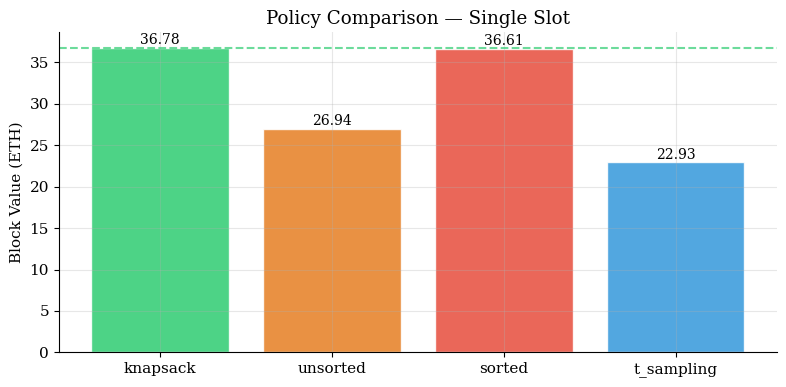

In [24]:
# Comparison of all algos

import os
os.makedirs('figures', exist_ok=True)

knapsack = sim.offline_knapsack(values, gas_costs, B)
greedy_unsorted = sim.greedy_unsorted(values, gas_costs, B)
greedy_sorted = sim.greedy_sorted(values, gas_costs, B)
t_sampling, thresholds = sim.thompson_sampling(values, gas_costs, B, mu=MU)

results = {
    'knapsack': knapsack,
    'unsorted': greedy_unsorted,
    'sorted': greedy_sorted,
    't_sampling': t_sampling,
}

print('Block values — one slot:')
for policy, val in results.items():
    ratio = val / knapsack if knapsack > 0 else 0
    print(f'  {policy.replace(chr(10)," "):25s}  {val:.3f} ETH  ({ratio:.1%} of OPT)')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']
bars = ax.bar(results.keys(), results.values(), color=colors, alpha=0.85, edgecolor='white')
ax.axhline(knapsack, color='#2ecc71', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_ylabel('Block Value (ETH)')
ax.set_title('Policy Comparison — Single Slot')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('figures/single_slot.png', dpi=150)
plt.show()


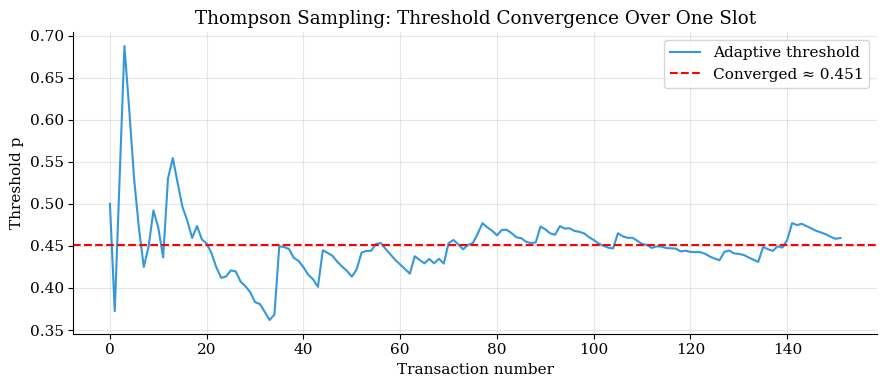

In [25]:
# Thompson Convergence

np.random.seed(42)
v_long = np.random.exponential(1.0, 200)
g_long = np.random.randint(1, 6, 200).astype(float)

t_sampling, thresholds = sim.thompson_sampling(v_long, g_long, B=100, mu=MU)

converged = np.mean(thresholds[-30:])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, color='#3498db', linewidth=1.5, label='Adaptive threshold')
ax.axhline(converged, color='red', linestyle='--', linewidth=1.5,
           label=f'Converged ≈ {converged:.3f}')
ax.set_xlabel('Transaction number')
ax.set_ylabel('Threshold p')
ax.set_title('Thompson Sampling: Threshold Convergence Over One Slot')
ax.legend()
plt.tight_layout()
plt.savefig('figures/thompson_convergence.png', dpi=150)
plt.show()


load=1  thompson=0.574  greedy=1.000
load=1  threshold=0.970  thompson=0.574  greedy=1.000
load=2  thompson=0.616  greedy=1.000
load=2  threshold=0.964  thompson=0.616  greedy=1.000
load=5  thompson=0.619  greedy=0.967
load=5  threshold=0.955  thompson=0.619  greedy=0.967
load=10  thompson=0.662  greedy=0.843
load=10  threshold=0.927  thompson=0.662  greedy=0.843
load=20  thompson=0.719  greedy=0.690
load=20  threshold=0.871  thompson=0.719  greedy=0.690
load=40  thompson=0.763  greedy=0.532
load=40  threshold=0.771  thompson=0.763  greedy=0.532


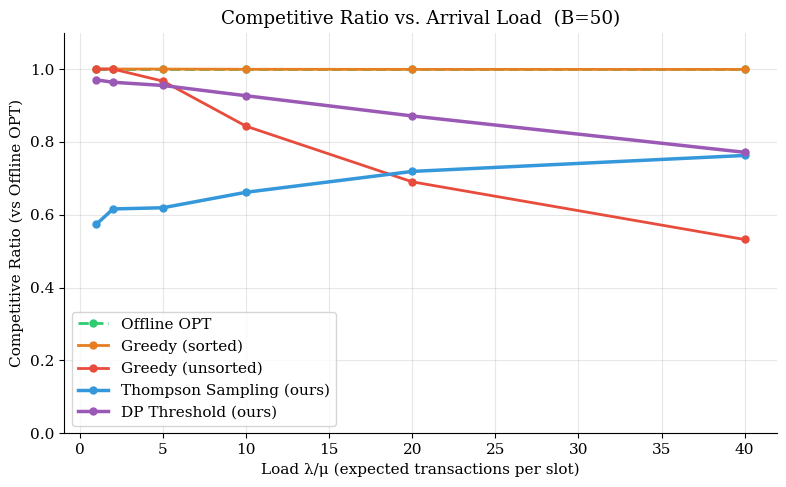

In [29]:
# Competitive Ratio

N_EPISODES = 2000
lam_values = [1, 2, 5, 10, 20, 40]
loads      = [l / MU for l in lam_values]

ratios = {'offline_knapsack': [], 'greedy_sorted': [],
          'greedy_unsorted': [], 'thompson': [], 'threshold': []}

rng = np.random.default_rng(SEED)
c_star = sim.compute_threshold(B=B, lam=LAM, mu=MU)

for lam in lam_values:
    bucket = {k: [] for k in ratios}
    for _ in range(N_EPISODES):
        T_slot = rng.exponential(1.0 / MU)
        n      = rng.poisson(lam * T_slot)
        if n == 0:
            for k in bucket: bucket[k].append(0.0)
            continue
        v = np.random.exponential(1.0, n)
        g = np.random.randint(1, 6, n).astype(float)
        threshold_val = sim.apply_threshold(v, g, c_star, B)
        bucket['threshold'].append(threshold_val)
        bucket['offline_knapsack'].append(sim.offline_knapsack(v, g, B))
        bucket['greedy_sorted'].append(sim.greedy_sorted(v, g, B))
        bucket['greedy_unsorted'].append(sim.greedy_unsorted(v, g, B))
        ts_val, _ = sim.thompson_sampling(v, g, B, mu=MU)
        bucket['thompson'].append(ts_val)

    opt_mean = np.mean(bucket['offline_knapsack'])
    for k in ratios:
        ratios[k].append(np.mean(bucket[k]) / opt_mean if opt_mean > 0 else 1.0)
    print(f'load={lam/MU:.0f}  thompson={ratios["thompson"][-1]:.3f}  greedy={ratios["greedy_unsorted"][-1]:.3f}')
    print(f'load={lam/MU:.0f}  threshold={ratios["threshold"][-1]:.3f}  thompson={ratios["thompson"][-1]:.3f}  greedy={ratios["greedy_unsorted"][-1]:.3f}')


fig, ax = plt.subplots(figsize=(8, 5))
labels = {'offline_knapsack': 'Offline OPT', 'greedy_sorted': 'Greedy (sorted)',
          'greedy_unsorted': 'Greedy (unsorted)', 'thompson': 'Thompson Sampling (ours)',
          'threshold': 'DP Threshold (ours)'}
styles = {'offline_knapsack': dict(color='#2ecc71', linestyle='--', linewidth=2),
          'greedy_sorted':    dict(color='#e67e22', linewidth=2),
          'greedy_unsorted':  dict(color='#e74c3c', linewidth=2),
          'thompson':         dict(color='#3498db', linewidth=2.5),
          'threshold':        dict(color='#9b59b6', linewidth=2.5)}
for k, vals in ratios.items():
    ax.plot(loads, vals, marker='o', markersize=5, label=labels[k], **styles[k])
ax.set_xlabel('Load λ/μ (expected transactions per slot)')
ax.set_ylabel('Competitive Ratio (vs Offline OPT)')
ax.set_title('Competitive Ratio vs. Arrival Load  (B=50)')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('figures/competitive_ratio.png', dpi=150)
plt.show()

Thompson vs Thompson: efficiency_loss=12.1%
Thompson vs Greedy: efficiency_loss=3.9%
Greedy vs Thompson: efficiency_loss=2.0%
Greedy vs Greedy: efficiency_loss=3.4%


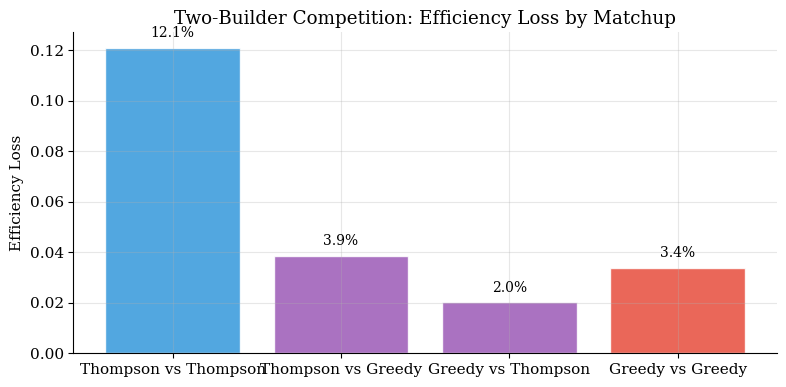

In [27]:
# Two builder competition

N_EPISODES = 2000
LAM = 15.0
rng2 = np.random.default_rng(SEED)

# single builder OPT baseline
single_opts = []
for _ in range(N_EPISODES):
    T_slot = rng2.exponential(1.0 / MU)
    n = rng2.poisson(LAM * T_slot)
    if n == 0: single_opts.append(0.0); continue
    v = np.random.exponential(1.0, n)
    g = np.random.randint(1, 6, n).astype(float)
    single_opts.append(sim.offline_knapsack(v, g, B))
single_opt_mean = np.mean(single_opts)

matchups = [('Thompson','Thompson'), ('Thompson','Greedy'),
            ('Greedy','Thompson'),   ('Greedy','Greedy')]
losses = []

for p1_name, p2_name in matchups:
    winners = []
    rng3 = np.random.default_rng(SEED + 1)
    for _ in range(N_EPISODES):
        T_slot = rng3.exponential(1.0 / MU)
        def draw():
            n = rng3.poisson(LAM * T_slot)
            if n == 0: return np.array([]), np.array([])
            return np.random.exponential(1.0, n), np.random.randint(1,6,n).astype(float)
        def run(name, v, g):
            if len(v) == 0: return 0.0
            if name == 'Thompson':
                val, _ = sim.thompson_sampling(v, g, B, mu=MU)
                return val
            return sim.greedy_unsorted(v, g, B)
        v1, g1 = draw()
        v2, g2 = draw()
        winners.append(max(run(p1_name,v1,g1), run(p2_name,v2,g2)))
    loss = 1.0 - np.mean(winners) / single_opt_mean
    losses.append(loss)
    print(f'{p1_name} vs {p2_name}: efficiency_loss={loss:.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
match_labels = [f'{p1} vs {p2}' for p1, p2 in matchups]
ax.bar(match_labels, losses, color=['#3498db','#9b59b6','#9b59b6','#e74c3c'],
       alpha=0.85, edgecolor='white')
for i, val in enumerate(losses):
    ax.text(i, val + 0.003, f'{val:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Efficiency Loss')
ax.set_title('Two-Builder Competition: Efficiency Loss by Matchup')
plt.tight_layout()
plt.savefig('figures/two_builder.png', dpi=150)
plt.show()

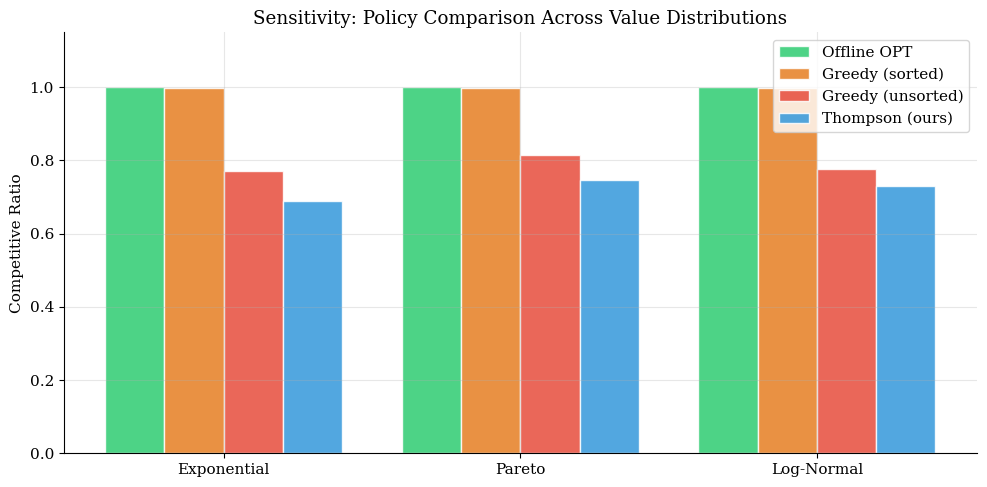

In [28]:
# Sensitivity

N_EPISODES = 1500
dists = {
    'Exponential': lambda n: np.random.exponential(1.0, n),
    'Pareto':      lambda n: (np.random.pareto(1.5, n) + 1),
    'Log-Normal':  lambda n: np.random.lognormal(0.0, 1.0, n),
}
policies = ['offline_knapsack', 'greedy_sorted', 'greedy_unsorted', 'thompson']
sens_results = {}

for dist_name, val_fn in dists.items():
    rng = np.random.default_rng(SEED)
    bucket = {p: [] for p in policies}
    for _ in range(N_EPISODES):
        T_slot = rng.exponential(1.0 / MU)
        n = rng.poisson(LAM * T_slot)
        if n == 0:
            for p in policies: bucket[p].append(0.0)
            continue
        v = val_fn(n)
        g = np.random.randint(1, 6, n).astype(float)
        bucket['offline_knapsack'].append(sim.offline_knapsack(v, g, B))
        bucket['greedy_sorted'].append(sim.greedy_sorted(v, g, B))
        bucket['greedy_unsorted'].append(sim.greedy_unsorted(v, g, B))
        ts_val, _ = sim.thompson_sampling(v, g, B, mu=MU)
        bucket['thompson'].append(ts_val)
    opt_mean = np.mean(bucket['offline_knapsack'])
    sens_results[dist_name] = {p: np.mean(bucket[p])/opt_mean for p in policies}

x = np.arange(len(dists))
width = 0.2
pol_labels = ['Offline OPT', 'Greedy (sorted)', 'Greedy (unsorted)', 'Thompson (ours)']
pol_colors = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(10, 5))
for i, (p, label, color) in enumerate(zip(policies, pol_labels, pol_colors)):
    vals = [sens_results[d][p] for d in dists]
    ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(dists.keys())
ax.set_ylabel('Competitive Ratio')
ax.set_title('Sensitivity: Policy Comparison Across Value Distributions')
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('figures/sensitivity.png', dpi=150)
plt.show()